# M3 — PINN Biomecánico (TFM)

| Parámetro | Valor |
|-----------|-------|
| Entrada X | `orientation` (45) + `acceleration` (15) → **60 features** |
| Salida y  | `smpl_pose` → **135 DOF** |
| Arquitectura | MLP 4 × 256, Tanh |
| Pérdida | MSE + λ · L_phy (λ = 0.1, 2ª diferencia finita) |
| Optimizador | Adam lr = 1e-3, CosineAnnealingLR |
| Batch / Épocas | 64 / 50 |

## 1. Montaje de Drive e imports

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Rutas ──────────────────────────────────────────────────────────────────
DATA_DIR  = '/content/drive/MyDrive/TFM_DT/DIPIMUandOthers'
CKPT_DIR  = '/content/drive/MyDrive/TFM_DT/DIPIMUandOthers/checkpoints_M3'
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Hiperparámetros ────────────────────────────────────────────────────────
INPUT_DIM  = 60    # orientation(45) + acceleration(15)
OUTPUT_DIM = 135   # smpl_pose
HIDDEN_DIM = 256
N_HIDDEN   = 4
LR         = 1e-3
BATCH_SIZE = 64
EPOCHS     = 50
LAMBDA_PHY = 0.1
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Carga de datos

In [16]:
def load_split(filename):
    path = os.path.join(DATA_DIR, filename)
    d = np.load(path, allow_pickle=True)
    ori_list  = list(d['orientation'])
    acc_list  = list(d['acceleration'])
    pose_list = list(d['smpl_pose'])
    X = np.concatenate([np.concatenate([o, a], axis=1) for o, a in zip(ori_list, acc_list)], axis=0).astype(np.float32)
    y = np.concatenate(pose_list, axis=0).astype(np.float32)
    return X, y

print('Cargando splits...')
X_train, y_train = load_split('imu_own_training.npz')
X_val,   y_val   = load_split('imu_own_validation.npz')
X_test,  y_test  = load_split('imu_own_test.npz')
print(f'Train: X{X_train.shape} y{y_train.shape}')
print(f'Val:   X{X_val.shape} y{y_val.shape}')
print(f'Test:  X{X_test.shape} y{y_test.shape}')


Cargando splits...
Train: X(252291, 60) y(252291, 135)
Val:   X(13116, 60) y(13116, 135)
Test:  X(51926, 60) y(51926, 135)


## 3. Normalización Z-score

In [17]:
# Estadísticas exclusivamente del split de entrenamiento
X_mean, X_std = X_train.mean(0), X_train.std(0) + 1e-8
y_mean, y_std = y_train.mean(0), y_train.std(0) + 1e-8

def norm_X(a):   return (a - X_mean) / X_std
def norm_y(a):   return (a - y_mean) / y_std
def denorm_y(a): return a * y_std + y_mean

X_tr = norm_X(X_train);  y_tr = norm_y(y_train)
X_vl = norm_X(X_val);    y_vl = norm_y(y_val)
X_te = norm_X(X_test);   y_te = norm_y(y_test)

np.savez(os.path.join(CKPT_DIR, 'norm_stats.npz'),
         X_mean=X_mean, X_std=X_std, y_mean=y_mean, y_std=y_std)
print('Estadísticas de normalización guardadas.')

Estadísticas de normalización guardadas.


## 4. Dataset y DataLoader

In [18]:
class PoseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(PoseDataset(X_tr, y_tr), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(PoseDataset(X_vl, y_vl), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(PoseDataset(X_te, y_te), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches → train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')

Batches → train: 3943  val: 205  test: 812


## 5. Arquitectura PINN

In [19]:
class PINN(nn.Module):
    """MLP 4×256 con activación Tanh e init Xavier."""
    def __init__(self):
        super().__init__()
        dims   = [INPUT_DIM] + [HIDDEN_DIM] * N_HIDDEN + [OUTPUT_DIM]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < N_HIDDEN:          # no activación en la capa de salida
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


model       = PINN().to(DEVICE)
n_params    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParámetros entrenables: {n_params:,}')

PINN(
  (net): Sequential(
    (0): Linear(in_features=60, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): Tanh()
    (8): Linear(in_features=256, out_features=135, bias=True)
  )
)

Parámetros entrenables: 247,687


## 6. Función de pérdida PINN

$$\mathcal{L} = \mathrm{MSE}(\hat{y},\,y) \;+\; \lambda\,\mathrm{MSE}\!\left(\Delta^2\hat{y},\,\Delta^2 y\right)$$

$\Delta^2 x_t = x_{t+2} - 2x_{t+1} + x_t$ aproxima la aceleración discreta de la trayectoria de poses.

In [20]:
_mse = nn.MSELoss()

def second_diff(t: torch.Tensor) -> torch.Tensor:
    """Segunda diferencia finita en la dimensión batch (T-2, D)."""
    return t[2:] - 2.0 * t[1:-1] + t[:-2]

def pinn_loss(pred: torch.Tensor, target: torch.Tensor):
    loss_data = _mse(pred, target)
    if pred.size(0) >= 3:
        loss_phy = _mse(second_diff(pred), second_diff(target))
    else:
        loss_phy = torch.zeros(1, device=pred.device)[0]
    total = loss_data + LAMBDA_PHY * loss_phy
    return total, loss_data.item(), loss_phy.item()

## 7. Entrenamiento

In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {k: [] for k in
           ['train_loss', 'train_mse', 'train_phy',
            'val_loss',   'val_mse',   'val_phy',  'lr']}

best_val   = float('inf')
best_ckpt  = os.path.join(CKPT_DIR, 'M3_PINN_best.pt')


def run_epoch(loader, train):
    model.train() if train else model.eval()
    acc_loss = acc_mse = acc_phy = n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb  = xb.to(DEVICE), yb.to(DEVICE)
            pred    = model(xb)
            loss, mse, phy = pinn_loss(pred, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            bs        = xb.size(0)
            acc_loss += loss.item() * bs
            acc_mse  += mse * bs
            acc_phy  += phy * bs
            n        += bs
    return acc_loss / n, acc_mse / n, acc_phy / n


hdr = f"{'Época':>6}  {'Train':>10}  {'Val':>10}  {'Val MSE':>10}  {'Val Phy':>10}  {'LR':>8}  {'s':>5}"
print(hdr)
print('-' * len(hdr))

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_mse, tr_phy = run_epoch(train_loader, train=True)
    vl_loss, vl_mse, vl_phy = run_epoch(val_loader,   train=False)
    scheduler.step()
    cur_lr = scheduler.get_last_lr()[0]

    for key, val in zip(
        ['train_loss','train_mse','train_phy','val_loss','val_mse','val_phy','lr'],
        [tr_loss, tr_mse, tr_phy, vl_loss, vl_mse, vl_phy, cur_lr]
    ):
        history[key].append(val)

    tag = ''
    if vl_loss < best_val:
        best_val = vl_loss
        torch.save({'epoch': epoch,
                    'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'val_loss': best_val}, best_ckpt)
        tag = ' ✓'

    if epoch % 5 == 0 or epoch == 1:
        torch.save({'epoch': epoch,
                    'model_state': model.state_dict(),
                    'val_loss': vl_loss},
                   os.path.join(CKPT_DIR, f'M3_PINN_epoch{epoch:03d}.pt'))

    elapsed = time.time() - t0
    print(f'{epoch:>6}  {tr_loss:>10.6f}  {vl_loss:>10.6f}  '
          f'{vl_mse:>10.6f}  {vl_phy:>10.6f}  {cur_lr:>8.2e}  {elapsed:>5.1f}{tag}')

print(f'\nEntrenamiento completado — mejor val_loss = {best_val:.6f}')

 Época       Train         Val     Val MSE     Val Phy        LR      s
-----------------------------------------------------------------------
     1    0.295817    0.975806    0.972968    0.028385  9.99e-04   21.8 ✓
     2    0.171516    0.974863    0.971859    0.030038  9.96e-04   21.8 ✓
     3    0.146272    1.049717    1.046714    0.030025  9.91e-04   21.5
     4    0.133683    1.026289    1.023145    0.031444  9.84e-04   20.8
     5    0.125966    1.014143    1.011082    0.030611  9.76e-04   21.5
     6    0.120378    0.987882    0.984671    0.032107  9.65e-04   21.1
     7    0.116058    0.993393    0.990014    0.033788  9.52e-04   21.2
     8    0.112595    1.004208    1.000880    0.033280  9.38e-04   20.9
     9    0.109903    0.992099    0.988633    0.034657  9.22e-04   21.4
    10    0.107432    1.008732    1.005251    0.034811  9.05e-04   20.9
    11    0.105236    1.048852    1.045268    0.035840  8.85e-04   21.4
    12    0.103287    1.021355    1.017693    0.036622  8.64

## 8. Evaluación en test

In [22]:
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Mejor checkpoint: época {ckpt['epoch']}  val_loss={ckpt['val_loss']:.6f}")

model.eval()
preds_n, tgts_n = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds_n.append(model(xb.to(DEVICE)).cpu().numpy())
        tgts_n.append(yb.numpy())

preds_n = np.concatenate(preds_n)
tgts_n  = np.concatenate(tgts_n)

# Desnormalizar al espacio original
preds   = denorm_y(preds_n)
targets = denorm_y(tgts_n)

# ── Métricas globales ──────────────────────────────────────────────────────
rmse_global  = float(np.sqrt(np.mean((preds - targets) ** 2)))
range_global = float(targets.max() - targets.min()) + 1e-8
nrmse_global = rmse_global / range_global
r2_global    = float(r2_score(targets, preds))

# ── Métricas por DOF ──────────────────────────────────────────────────────
rmse_dof  = np.sqrt(np.mean((preds - targets) ** 2, axis=0))
range_dof = (targets.max(axis=0) - targets.min(axis=0)) + 1e-8
nrmse_dof = rmse_dof / range_dof
r2_dof    = np.array([r2_score(targets[:, i], preds[:, i])
                       for i in range(OUTPUT_DIM)])

print('=' * 48)
print(f'  RMSE  global : {rmse_global:.6f}')
print(f'  nRMSE global : {nrmse_global:.4%}')
print(f'  R²    global : {r2_global:.6f}')
print('-' * 48)
print(f'  RMSE  / DOF  media={rmse_dof.mean():.6f}  std={rmse_dof.std():.6f}')
print(f'  nRMSE / DOF  media={nrmse_dof.mean():.4%}  std={nrmse_dof.std():.4%}')
print(f'  R²    / DOF  media={r2_dof.mean():.6f}  std={r2_dof.std():.6f}')
print('=' * 48)

np.savez(os.path.join(CKPT_DIR, 'M3_metrics.npz'),
         rmse=rmse_global, nrmse=nrmse_global, r2=r2_global,
         rmse_dof=rmse_dof, nrmse_dof=nrmse_dof, r2_dof=r2_dof)
print('Métricas guardadas.')

Mejor checkpoint: época 2  val_loss=0.974863
  RMSE  global : 0.144190
  nRMSE global : 7.2095%
  R²    global : 0.298190
------------------------------------------------
  RMSE  / DOF  media=0.123667  std=0.074143
  nRMSE / DOF  media=11.1875%  std=3.1007%
  R²    / DOF  media=0.298146  std=0.626673
Métricas guardadas.


## 9. Visualización de resultados

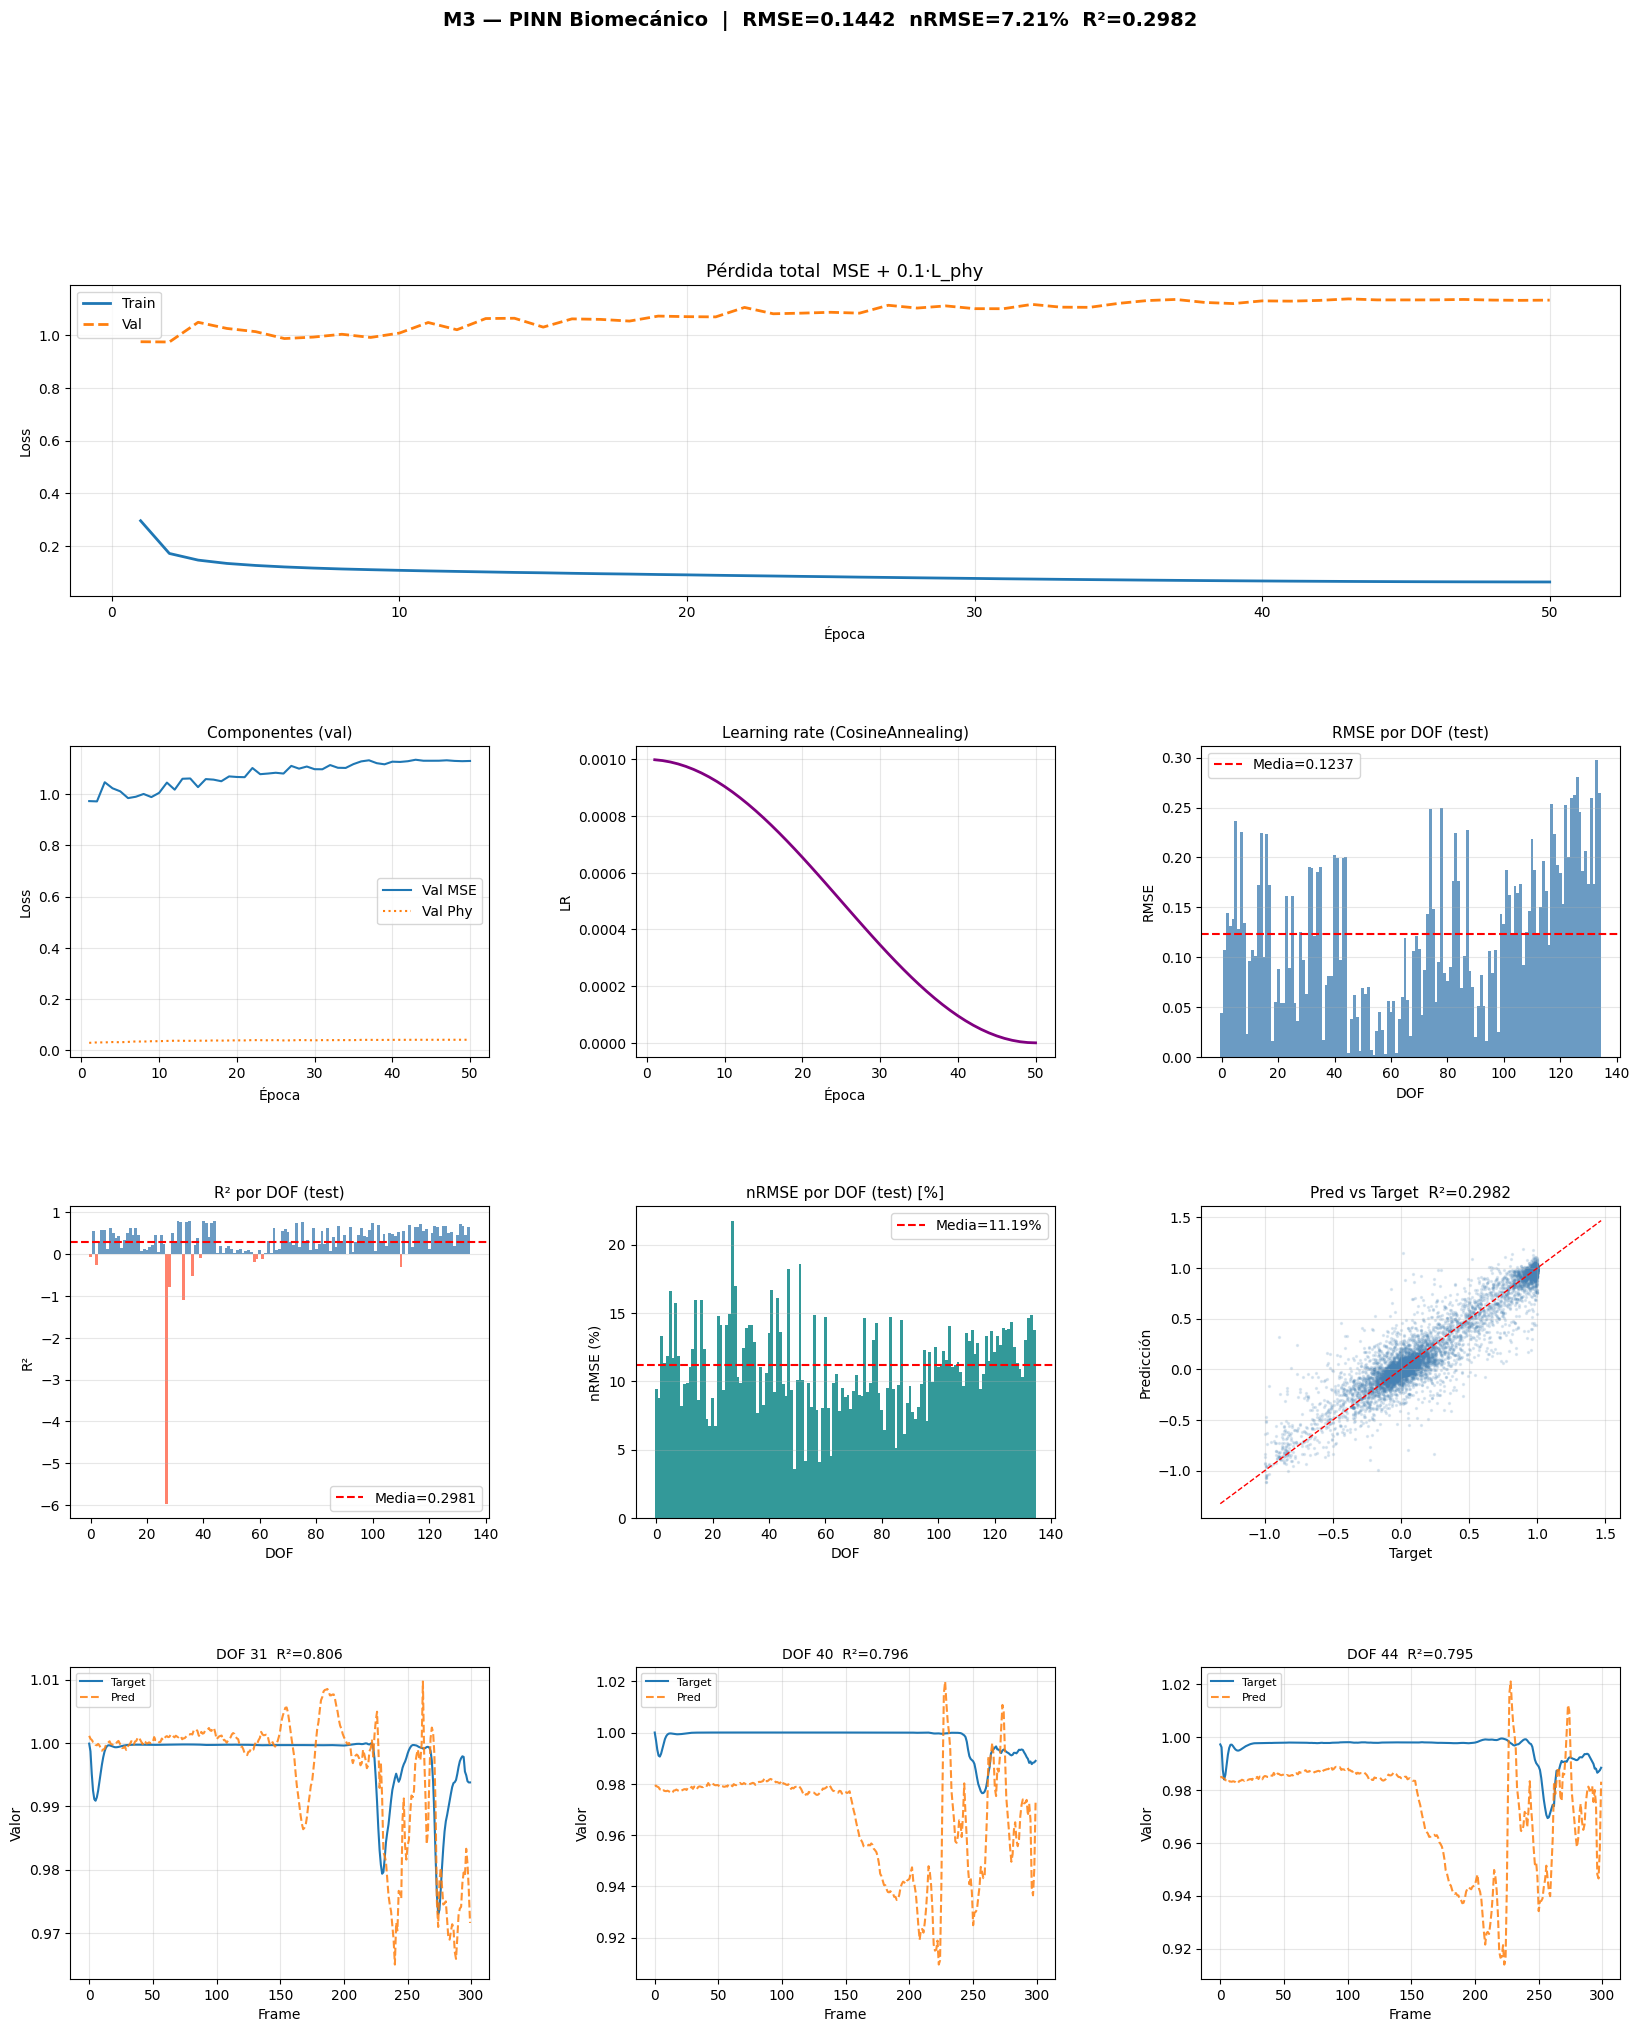

Figura guardada: /content/drive/MyDrive/TFM_DT/DIPIMUandOthers/checkpoints_M3/M3_PINN_results.png


In [23]:
ep = np.arange(1, EPOCHS + 1)

fig = plt.figure(figsize=(20, 22))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.48, wspace=0.35)

# ── A. Pérdida total ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(ep, history['train_loss'], lw=2,       label='Train')
ax.plot(ep, history['val_loss'],   lw=2, ls='--', label='Val')
ax.set_title('Pérdida total  MSE + 0.1·L_phy', fontsize=13)
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# ── B. Componentes de pérdida (val) ───────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(ep, history['val_mse'], label='Val MSE')
ax.plot(ep, history['val_phy'], label='Val Phy', ls=':')
ax.set_title('Componentes (val)', fontsize=11)
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# ── C. Learning rate ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(ep, history['lr'], color='purple', lw=2)
ax.set_title('Learning rate (CosineAnnealing)', fontsize=11)
ax.set_xlabel('Época'); ax.set_ylabel('LR')
ax.grid(alpha=0.3)

# ── D. RMSE por DOF ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.bar(np.arange(OUTPUT_DIM), rmse_dof, width=1.0, color='steelblue', alpha=0.8)
ax.axhline(rmse_dof.mean(), color='red', ls='--',
           label=f'Media={rmse_dof.mean():.4f}')
ax.set_title('RMSE por DOF (test)', fontsize=11)
ax.set_xlabel('DOF'); ax.set_ylabel('RMSE')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── E. R² por DOF ─────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
colors = ['steelblue' if v >= 0 else 'tomato' for v in r2_dof]
ax.bar(np.arange(OUTPUT_DIM), r2_dof, width=1.0, color=colors, alpha=0.8)
ax.axhline(r2_dof.mean(), color='red', ls='--',
           label=f'Media={r2_dof.mean():.4f}')
ax.set_title('R² por DOF (test)', fontsize=11)
ax.set_xlabel('DOF'); ax.set_ylabel('R²')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── F. nRMSE por DOF ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
ax.bar(np.arange(OUTPUT_DIM), nrmse_dof * 100, width=1.0, color='teal', alpha=0.8)
ax.axhline(nrmse_dof.mean() * 100, color='red', ls='--',
           label=f'Media={nrmse_dof.mean()*100:.2f}%')
ax.set_title('nRMSE por DOF (test) [%]', fontsize=11)
ax.set_xlabel('DOF'); ax.set_ylabel('nRMSE (%)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── G. Scatter global ─────────────────────────────────────────────────────
ax  = fig.add_subplot(gs[2, 2])
rng = np.random.default_rng(0)
idx = rng.choice(preds.size, min(8000, preds.size), replace=False)
ax.scatter(targets.ravel()[idx], preds.ravel()[idx],
           alpha=0.15, s=2, color='steelblue')
lim = [min(targets.min(), preds.min()), max(targets.max(), preds.max())]
ax.plot(lim, lim, 'r--', lw=1)
ax.set_title(f'Pred vs Target  R²={r2_global:.4f}', fontsize=11)
ax.set_xlabel('Target'); ax.set_ylabel('Predicción')
ax.grid(alpha=0.3)

# ── H. Pred vs target — 3 mejores DOF (por R²) ────────────────────────────
top3   = np.argsort(r2_dof)[-3:][::-1]
n_show = min(300, len(targets))
t_idx  = np.arange(n_show)

for col, dof in enumerate(top3):
    ax = fig.add_subplot(gs[3, col])
    ax.plot(t_idx, targets[:n_show, dof], lw=1.5,           label='Target')
    ax.plot(t_idx, preds[:n_show,   dof], lw=1.5, ls='--',  label='Pred', alpha=0.85)
    ax.set_title(f'DOF {dof}  R²={r2_dof[dof]:.3f}', fontsize=10)
    ax.set_xlabel('Frame'); ax.set_ylabel('Valor')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle(
    f'M3 — PINN Biomecánico  |  '
    f'RMSE={rmse_global:.4f}  nRMSE={nrmse_global:.2%}  R²={r2_global:.4f}',
    fontsize=14, fontweight='bold', y=1.005
)

out_fig = os.path.join(CKPT_DIR, 'M3_PINN_results.png')
fig.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {out_fig}')

## 10. Resumen

In [24]:
print('\n' + '=' * 52)
print('  RESUMEN M3 — PINN BIOMECÁNICO')
print('=' * 52)
print(f'  Entrada  : orientation(45) + acceleration(15) = {INPUT_DIM}')
print(f'  Salida   : smpl_pose = {OUTPUT_DIM} DOF')
print(f'  Arq.     : MLP {N_HIDDEN}×{HIDDEN_DIM}, Tanh')
print(f'  Params   : {n_params:,}')
print(f'  Loss     : MSE + {LAMBDA_PHY}·L_phy (2ª derivada temporal)')
print(f'  Optim.   : Adam lr={LR}, CosineAnnealingLR T_max={EPOCHS}')
print(f'  Épocas   : {EPOCHS}   Batch: {BATCH_SIZE}')
print('-' * 52)
print(f'  RMSE     : {rmse_global:.6f}')
print(f'  nRMSE    : {nrmse_global:.4%}')
print(f'  R²       : {r2_global:.6f}')
print('-' * 52)
print(f'  Ckpts    : {CKPT_DIR}')
print('=' * 52)


  RESUMEN M3 — PINN BIOMECÁNICO
  Entrada  : orientation(45) + acceleration(15) = 60
  Salida   : smpl_pose = 135 DOF
  Arq.     : MLP 4×256, Tanh
  Params   : 247,687
  Loss     : MSE + 0.1·L_phy (2ª derivada temporal)
  Optim.   : Adam lr=0.001, CosineAnnealingLR T_max=50
  Épocas   : 50   Batch: 64
----------------------------------------------------
  RMSE     : 0.144190
  nRMSE    : 7.2095%
  R²       : 0.298190
----------------------------------------------------
  Ckpts    : /content/drive/MyDrive/TFM_DT/DIPIMUandOthers/checkpoints_M3
